# Designing the next chatbot experiment

The first notebook showed us **what happened** in the A/B test. The second notebook showed us how the same result looks through a **Bayesian** lens.

This notebook tackles the next practical question:

> *What should we test next, and how long should that test run?*

That is where **experiment design** and **power planning** become useful. A test can fail to produce a usable decision for two very different reasons:

- the product change may genuinely not help
- the metric may be too sparse, or the test may be too short, to detect a realistic improvement

Our goal here is to turn the previous analysis into an **actionable next-test plan** for the chatbot.


In [1]:
# Notebook setup
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Load the planning inputs

We will use **both** project datasets:

- `data/data_summary.csv` for the funnel totals by variation
- `data/data.csv` for timestamp-based traffic estimation

That gives us enough information to estimate both the **sample size** we need and the **runtime** we should expect.


In [2]:
summary_df = pd.read_csv("data/data_summary.csv")
raw_df = pd.read_csv("data/data.csv", low_memory=False)
raw_df["experiment_viewed_ga_first_timestamp"] = pd.to_datetime(
    raw_df["experiment_viewed_ga_first_timestamp"], utc=True
)

print("summary_df shape:", summary_df.shape)
print("raw_df shape:", raw_df.shape)
summary_df

summary_df shape: (2, 10)
raw_df shape: (66040, 15)


,variation_ga,experiment_viewed_ga_first_binary,experiment_assignment_hubspot_binary,application_started_first_binary,form_interaction_first_binary,application_first_binary,lead_first_binary,interview_first_binary,admitted_first_binary,financing_confirmed_first_binary
0,False,32984,1337,11613,6562,1205,1364,121,55,12
1,True,33056,1236,9738,5659,1147,1259,124,60,9


## Helper functions

To keep the notebook reusable, we will define a few compact helpers:

- one to extract metric-level counts and rates from the summary table
- one to compute required sample size per group for a two-proportion test
- one to translate sample size into expected runtime based on observed traffic

These helpers are intentionally small enough that you can reuse them for future A/B test planning.


In [3]:
def get_metric_stats(summary_df, metric_col):
    control_row = summary_df.loc[~summary_df["variation_ga"]].iloc[0]
    treatment_row = summary_df.loc[summary_df["variation_ga"]].iloc[0]

    control_trials = int(control_row["experiment_viewed_ga_first_binary"])
    treatment_trials = int(treatment_row["experiment_viewed_ga_first_binary"])
    control_conversions = int(control_row[metric_col])
    treatment_conversions = int(treatment_row[metric_col])

    return {
        "metric_col": metric_col,
        "control_trials": control_trials,
        "treatment_trials": treatment_trials,
        "control_conversions": control_conversions,
        "treatment_conversions": treatment_conversions,
        "control_rate": control_conversions / control_trials,
        "treatment_rate": treatment_conversions / treatment_trials,
        "observed_relative_change": (treatment_conversions / treatment_trials)
        / (control_conversions / control_trials)
        - 1,
    }


def required_sample_size_per_group_two_proportions(
    baseline_rate, relative_lift, significance_level=0.05, power_target=0.80
):
    if baseline_rate <= 0:
        raise ValueError("baseline_rate must be positive")
    if relative_lift <= 0:
        raise ValueError("relative_lift must be positive")

    target_rate = baseline_rate * (1 + relative_lift)
    if target_rate >= 1:
        raise ValueError("target_rate must stay below 1")

    z_alpha = norm.ppf(1 - significance_level / 2)
    z_beta = norm.ppf(power_target)
    pooled_rate = (baseline_rate + target_rate) / 2

    numerator = (
        z_alpha * np.sqrt(2 * pooled_rate * (1 - pooled_rate))
        + z_beta
        * np.sqrt(baseline_rate * (1 - baseline_rate) + target_rate * (1 - target_rate))
    ) ** 2
    denominator = (target_rate - baseline_rate) ** 2

    return int(np.ceil(numerator / denominator)), target_rate


def estimate_days_needed(required_sample_size_per_group, avg_daily_users_per_group):
    if avg_daily_users_per_group <= 0:
        raise ValueError("avg_daily_users_per_group must be positive")
    return required_sample_size_per_group / avg_daily_users_per_group

## Observed experiment traffic

Before choosing a primary metric, we need to understand the traffic we can realistically rely on.

The original experiment produced roughly the following amount of traffic per day. We estimate runtime from **observed experiment viewers**, because that is the top-of-funnel population that gets randomized into control and treatment.


In [4]:
planning_daily_traffic = (
    raw_df.assign(
        experiment_day=raw_df["experiment_viewed_ga_first_timestamp"].dt.floor("D")
    )
    .groupby("experiment_day")["user_id"]
    .count()
    .sort_index()
)

planning_avg_daily_users_total = planning_daily_traffic.mean()
planning_avg_daily_users_per_group = planning_avg_daily_users_total / 2
planning_observed_days = len(planning_daily_traffic)

planning_traffic_summary = pd.DataFrame(
    {
        "metric": [
            "Observed experiment days",
            "Average daily viewers (total)",
            "Average daily viewers per group",
            "Median daily viewers (total)",
        ],
        "value": [
            planning_observed_days,
            round(planning_avg_daily_users_total, 1),
            round(planning_avg_daily_users_per_group, 1),
            float(planning_daily_traffic.median()),
        ],
    }
)

planning_traffic_summary

,metric,value
0,Observed experiment days,69.0
1,Average daily viewers (total),957.1
2,Average daily viewers per group,478.6
3,Median daily viewers (total),983.0


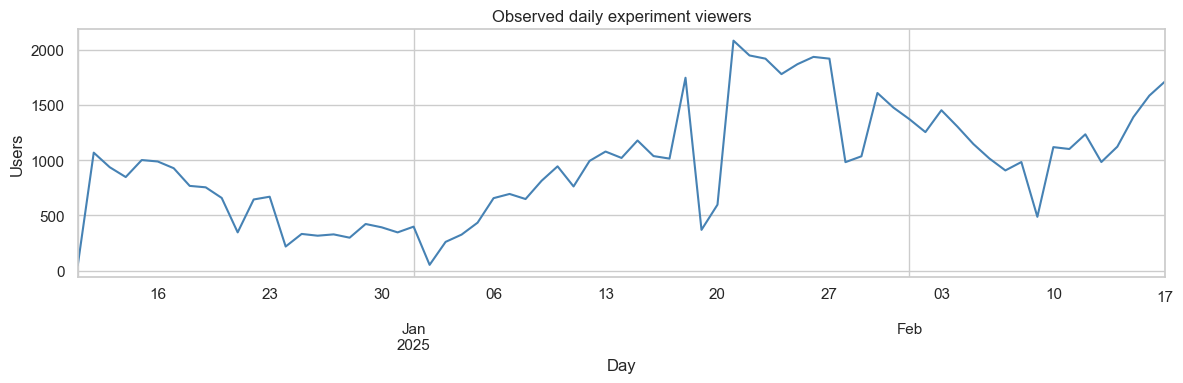

In [5]:
plt.figure(figsize=(12, 4))
planning_daily_traffic.plot(color="steelblue")
plt.title("Observed daily experiment viewers")
plt.xlabel("Day")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

## Candidate primary metrics

A good primary metric should balance **business relevance** and **statistical feasibility**.

We will compare three candidates:

- `application_started_first_binary`
- `lead_first_binary`
- `financing_confirmed_first_binary`

This is a useful spread because these metrics represent three different points in the funnel:

- an **early** action that is easy to measure
- a **mid-funnel** business metric that is still reasonably frequent
- a **very late** business metric that is extremely sparse

For comparison, we will ask a practical planning question:

> *If we wanted to detect a 10% relative lift on this metric, how large and how long would the next experiment need to be?*


In [6]:
planning_metric_candidates = [
    {
        "metric_col": "application_started_first_binary",
        "metric_name": "Application started",
        "business_relevance": "Medium",
        "measurement_note": "Easy to measure, but still an early-funnel proxy.",
    },
    {
        "metric_col": "lead_first_binary",
        "metric_name": "Lead",
        "business_relevance": "High",
        "measurement_note": "Closer to revenue and more reliable than application submission in this project.",
    },
    {
        "metric_col": "financing_confirmed_first_binary",
        "metric_name": "Financing confirmed",
        "business_relevance": "Very high",
        "measurement_note": "Closest to money, but extremely sparse.",
    },
]

planning_candidate_rows = []
for candidate in planning_metric_candidates:
    metric_stats = get_metric_stats(summary_df, candidate["metric_col"])
    planning_required_sample_size_10pct, _ = (
        required_sample_size_per_group_two_proportions(
            baseline_rate=metric_stats["control_rate"],
            relative_lift=0.10,
        )
    )
    planning_estimated_days_10pct = estimate_days_needed(
        planning_required_sample_size_10pct, planning_avg_daily_users_per_group
    )

    if planning_estimated_days_10pct <= 30:
        planning_verdict = "Feasible primary metric"
    elif planning_estimated_days_10pct <= 90:
        planning_verdict = "Possible, but slower"
    else:
        planning_verdict = "Too slow for a primary metric"

    planning_candidate_rows.append(
        {
            "metric": candidate["metric_name"],
            "control_conversions": metric_stats["control_conversions"],
            "control_rate_pct": round(metric_stats["control_rate"] * 100, 3),
            "observed_relative_change_pct": round(
                metric_stats["observed_relative_change"] * 100, 1
            ),
            "business_relevance": candidate["business_relevance"],
            "sample_size_per_group_for_10pct_lift": planning_required_sample_size_10pct,
            "estimated_days_for_10pct_lift": round(planning_estimated_days_10pct, 1),
            "verdict": planning_verdict,
            "measurement_note": candidate["measurement_note"],
        }
    )

planning_candidate_df = pd.DataFrame(planning_candidate_rows)
planning_candidate_df

,metric,control_conversions,control_rate_pct,observed_relative_change_pct,business_relevance,sample_size_per_group_for_10pct_lift,estimated_days_for_10pct_lift,verdict,measurement_note
0,Application started,11613,35.208,-16.3,Medium,2950,6.2,Feasible primary metric,"Easy to measure, but still an early-funnel proxy."
1,Lead,1364,4.135,-7.9,High,38127,79.7,"Possible, but slower",Closer to revenue and more reliable than appli...
2,Financing confirmed,12,0.036,-25.2,Very high,4528799,9463.6,Too slow for a primary metric,"Closest to money, but extremely sparse."


## Metric recommendation

The comparison above gives us the central tradeoff.

### Why not `application_started_first_binary` as the primary metric?

It is much easier to power, but it is still an **early-funnel** action. It tells us whether people took an initial step, not whether the chatbot improved a business outcome we actually care about.

### Why not `financing_confirmed_first_binary` as the primary metric?

It is the most business-relevant metric, but it is far too sparse for this traffic level. Using it as the primary metric would make the experiment **painfully long** and therefore impractical.

### Why `lead_first_binary` is the best primary metric here

`lead_first_binary` is the best compromise because it is:

- **closer to revenue** than an early click or form interaction
- **much more feasible** than financing-confirmed users
- described in notebook 1 as more reliable in this project than the GA-based application-submission event

> For the next chatbot experiment, `lead_first_binary` should be the **primary metric**.

We can still keep early-funnel metrics in the analysis, but they should support the decision rather than drive it.


In [7]:
planning_metric_roles = pd.DataFrame(
    [
        {
            "role": "Primary metric",
            "metric": "lead_first_binary",
            "why": "Closest practical business metric with enough signal to plan a realistic experiment.",
        },
        {
            "role": "Secondary metric",
            "metric": "application_started_first_binary",
            "why": "Useful early indicator of whether the chatbot changes top-of-funnel behaviour.",
        },
        {
            "role": "Secondary metric",
            "metric": "form_interaction_first_binary",
            "why": "Helpful diagnostic metric for engagement with the application flow.",
        },
        {
            "role": "Do not use as primary",
            "metric": "financing_confirmed_first_binary",
            "why": "Too sparse for this traffic level.",
        },
    ]
)

planning_metric_roles

,role,metric,why
0,Primary metric,lead_first_binary,Closest practical business metric with enough ...
1,Secondary metric,application_started_first_binary,Useful early indicator of whether the chatbot ...
2,Secondary metric,form_interaction_first_binary,Helpful diagnostic metric for engagement with ...
3,Do not use as primary,financing_confirmed_first_binary,Too sparse for this traffic level.


## Power planning and minimum detectable effect

Power planning answers a simple but important question:

> *How many users do we need per group to detect a realistic improvement?*

In practice, the answer depends on four things:

- the **baseline conversion rate** of the metric
- the **minimum detectable effect (MDE)** we care about
- the **significance level** we choose
- the **power target** we choose

In this notebook, we will use the common defaults:

- significance level: `0.05`
- power target: `0.80`

We will plan the next experiment around the `lead_first_binary` baseline observed in the control group.


In [8]:
planning_lead_stats = get_metric_stats(summary_df, "lead_first_binary")
planning_baseline_rate = planning_lead_stats["control_rate"]
planning_significance_level = 0.05
planning_power_target = 0.80
planning_relative_lift_scenarios = [0.05, 0.10, 0.15, 0.20]

planning_scenario_rows = []
for planning_relative_lift in planning_relative_lift_scenarios:
    planning_required_sample_size, planning_target_rate = (
        required_sample_size_per_group_two_proportions(
            baseline_rate=planning_baseline_rate,
            relative_lift=planning_relative_lift,
            significance_level=planning_significance_level,
            power_target=planning_power_target,
        )
    )
    planning_days_needed = estimate_days_needed(
        planning_required_sample_size, planning_avg_daily_users_per_group
    )
    planning_scenario_rows.append(
        {
            "relative_lift_pct": int(planning_relative_lift * 100),
            "baseline_rate_pct": round(planning_baseline_rate * 100, 3),
            "target_rate_pct": round(planning_target_rate * 100, 3),
            "required_sample_size_per_group": planning_required_sample_size,
            "estimated_days": round(planning_days_needed, 1),
        }
    )

planning_scenarios_df = pd.DataFrame(planning_scenario_rows)
planning_scenarios_df

,relative_lift_pct,baseline_rate_pct,target_rate_pct,required_sample_size_per_group,estimated_days
0,5,4.135,4.342,149038,311.4
1,10,4.135,4.549,38127,79.7
2,15,4.135,4.756,17330,36.2
3,20,4.135,4.962,9963,20.8


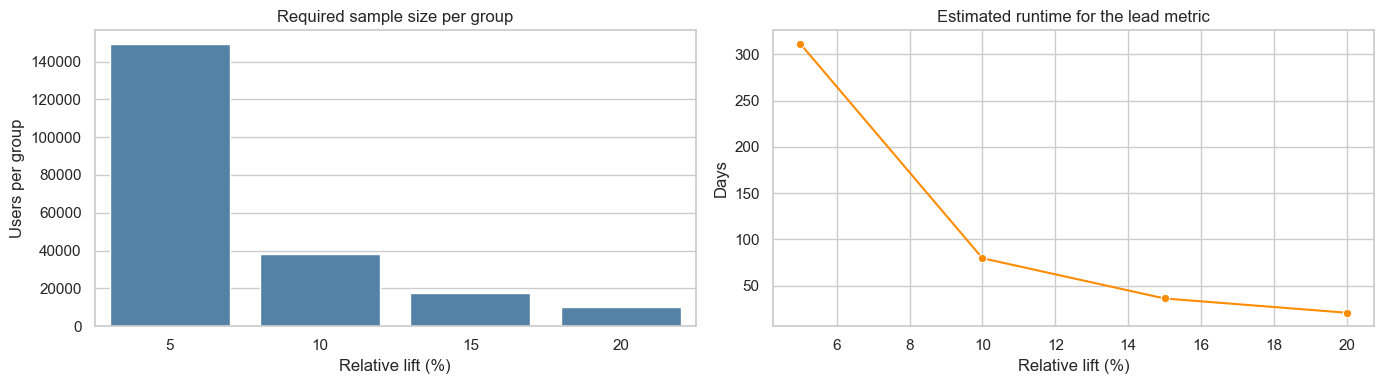

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=planning_scenarios_df,
    x="relative_lift_pct",
    y="required_sample_size_per_group",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Required sample size per group")
axes[0].set_xlabel("Relative lift (%)")
axes[0].set_ylabel("Users per group")

sns.lineplot(
    data=planning_scenarios_df,
    x="relative_lift_pct",
    y="estimated_days",
    marker="o",
    color="darkorange",
    ax=axes[1],
)
axes[1].set_title("Estimated runtime for the lead metric")
axes[1].set_xlabel("Relative lift (%)")
axes[1].set_ylabel("Days")

plt.tight_layout()
plt.show()

## Interpreting the planning scenarios

The scenario table tells a very practical story:

- detecting a **5%** lift in leads would take far too long to be useful
- detecting a **10%** lift is possible, but still slow at this traffic level
- detecting a **15%** lift is much more realistic for an iteration cycle
- detecting a **20%** lift is faster, but may be too optimistic as a planning target

That makes **15% relative lift in leads** a sensible planning target for the next experiment:

- it is still meaningfully business-relevant
- it keeps the experiment within a realistic operating window
- it avoids pretending that tiny lifts are cheap to measure

To reduce the risk of weekday effects and early noise, we will add a full-week buffer on top of the estimated runtime when writing the next-test brief.


In [10]:
planning_target_relative_lift = 0.15
planning_target_row = planning_scenarios_df.loc[
    planning_scenarios_df["relative_lift_pct"]
    == int(planning_target_relative_lift * 100)
].iloc[0]
planning_required_sample_size = int(
    planning_target_row["required_sample_size_per_group"]
)
planning_days_needed = float(planning_target_row["estimated_days"])
planning_recommended_minimum_runtime_days = max(int(np.ceil(planning_days_needed)), 42)

planning_target_row.to_frame(name="value")

,value
relative_lift_pct,15.000
baseline_rate_pct,4.135
target_rate_pct,4.756
required_sample_size_per_group,17330.000
estimated_days,36.200


## Practical experiment redesign

We can now turn the planning work into a concrete experiment brief.

The most important shift is this:

> Do **not** rerun the same broad chatbot and hope that the statistics will save it.

Instead, run a **narrower chatbot v2** that is easier to justify as a product hypothesis. For example, the next variant should focus on:

- answering **high-intent admissions questions**
- creating a clearer **handoff to the application flow**
- making the experience more concise and **mobile-friendly**
- escalating unclear cases to a human rather than trying to answer everything

This gives the next A/B test a sharper product story and a more realistic chance of improving the primary metric.


In [11]:
planning_next_test_brief = pd.DataFrame(
    [
        {
            "field": "Hypothesis",
            "value": "A narrower, more actionable chatbot v2 will increase lead conversion by at least 15% relative to the current experience.",
        },
        {
            "field": "Primary metric",
            "value": "lead_first_binary",
        },
        {
            "field": "Secondary metrics",
            "value": "application_started_first_binary, form_interaction_first_binary",
        },
        {
            "field": "Significance level",
            "value": planning_significance_level,
        },
        {
            "field": "Power target",
            "value": planning_power_target,
        },
        {
            "field": "Planning target",
            "value": "+15% relative lift in lead conversion",
        },
        {
            "field": "Required sample size per group",
            "value": planning_required_sample_size,
        },
        {
            "field": "Observed average daily viewers per group",
            "value": round(planning_avg_daily_users_per_group, 1),
        },
        {
            "field": "Estimated runtime from traffic",
            "value": f"{planning_days_needed:.1f} days",
        },
        {
            "field": "Recommended minimum runtime",
            "value": f"{planning_recommended_minimum_runtime_days} days",
        },
        {
            "field": "Decision rule",
            "value": "Do not call the test early based only on interview, admitted, or financing-confirmed movements. Use the primary metric first.",
        },
    ]
)

planning_next_test_brief

,field,value
0,Hypothesis,"A narrower, more actionable chatbot v2 will in..."
1,Primary metric,lead_first_binary
2,Secondary metrics,"application_started_first_binary, form_interac..."
3,Significance level,0.05
4,Power target,0.8
5,Planning target,+15% relative lift in lead conversion
6,Required sample size per group,17330
7,Observed average daily viewers per group,478.6
8,Estimated runtime from traffic,36.2 days
9,Recommended minimum runtime,42 days


## Conclusion

Notebook 1 and notebook 2 told us that the original chatbot experiment did **not** give us a strong case for rollout.

This notebook adds the missing operational conclusion:

- keep `lead_first_binary` as the **primary metric** for the next experiment
- keep `application_started_first_binary` and `form_interaction_first_binary` as **secondary diagnostic metrics**
- do **not** use `financing_confirmed_first_binary` as the primary metric at the current traffic level
- plan the next test around roughly a **15% relative lift target**
- run the next experiment for at least **42 days** before making a decision

If we follow that plan, the next A/B test will be much more likely to answer a question that is both **statistically valid** and **commercially meaningful**.


# Additional explanations: 

This is the perfect concluding chapter. If Notebook 1 was about **playing the Referee** (looking at past data to see who won) and Notebook 2 was about **playing the Detective** (updating your beliefs as clues arrive), Notebook 3 is about **playing the Architect** (designing a smarter building for next time).

Here is a summary of the core practical takeaways from this final chapter:

### 1. The "Goldilocks" Metric (The Funnel Trade-Off)

When deciding what to measure in your next test, you have to balance **business value** with **statistical reality**. The chapter perfectly illustrates this using the conversion funnel:

* **Top of Funnel (Application Started):** High traffic. It is very easy to get statistical significance quickly. However, it has **low business value**—just because someone clicks a button doesn't mean they will pay for a bootcamp.
* **Bottom of Funnel (Financing Confirmed):** Ultimate business value (it equals real money). However, it is **too sparse**. Only 12 people achieved this in the entire dataset. A test measuring this would literally take years to reach statistical significance.
* **Middle of Funnel (Lead / Form Submitted):** The "Goldilocks" metric. It is close enough to revenue that the business cares, but it has enough traffic (~1,300 people) that you can actually finish a statistical test in a reasonable timeframe.

### 2. The Reality of Target Lifts

The math of A/B testing is cruel: detecting tiny improvements takes massive amounts of time.

* Detecting a **5% improvement** would take too long for a fast-moving tech company.
* Detecting a **20% improvement** is fast to measure, but usually unrealistic for a product team to actually achieve.
* The team settled on a **15% target lift**. It is a meaningful improvement that can be measured in a realistic time window.

### 3. The Experiment Brief (The Contract)

Before launching Chatbot v2, the data scientist writes an Experiment Brief. This is essentially a contract with the business that prevents "HiPPOs" from ruining the test later. It establishes strict rules:

* **The Goal:** A 15% lift in Leads.
* **The Timeline:** The test must run for at least **42 days**.
* **The Rule:** Do *not* stop the test early just because a secondary metric looks good or bad. Stick to the primary metric.

### 4. Product Iteration (Don't just re-roll the dice)

Perhaps the most important business lesson here is that you don't just rerun a failed test and hope the math changes. Because Chatbot v1 failed, the team created a clear hypothesis for **Chatbot v2**: make it narrower, mobile-friendly, and focused purely on admissions questions rather than general chatter.

---

### Your Entire A/B Testing Journey Summarized

You have just completed a highly realistic, end-to-end corporate data science workflow:

1. **You cleaned the data** (removing contaminated users who saw both versions).
2. **You ran a Frequentist test** (proving mathematically that Chatbot v1 decreased conversions).
3. **You ran a Bayesian test** (proving to stakeholders that there was almost zero probability the bot was secretly better).
4. **You designed the future** (setting up a strict, mathematically sound roadmap for testing Chatbot v2).

This is exactly how Senior Data Scientists operate at top tech companies.

Do you have any final questions about this curriculum, or are you ready to close the book on the Chatbot A/B testing project?

# Group task: 🤖 SCENARIO 2: AI Assistant (Improving LLM Quality)


## Cell 1: Required Imports

Run this first to load your statistical and plotting libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set styling for plots
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Cell 2: Generate Synthetic Data (A vs. C)

This cell generates realistic 1-5 star satisfaction ratings for your two groups.

In [3]:
np.random.seed(303)

# Traffic split
n_A = 1200  # Control (Current Prompt)
n_C = 1300 # Test (Structured CoT Prompt)

# Define probabilities for 1, 2, 3, 4, 5 star ratings
# Control (A) leans towards average/mediocre scores (3s and 4s)
score_A = np.random.choice([1, 2, 3, 4, 5], size=n_A, p=[0.10, 0.20, 0.40, 0.20, 0.10]) 

# Test (C) leans heavily towards high satisfaction (4s and 5s)
score_C = np.random.choice([1, 2, 3, 4, 5], size=n_C, p=[0.02, 0.08, 0.20, 0.40, 0.30]) 

# Build DataFrames
df_A = pd.DataFrame({'user_id': range(1, n_A + 1), 'variant': 'A (Current)', 'score': score_A})
df_C = pd.DataFrame({'user_id': range(n_A + 1, n_A + n_C + 1), 'variant': 'C (Structured CoT)', 'score': score_C})

# Combine and shuffle
df = pd.concat([df_A, df_C]).sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv('ai_satisfaction_AvsC.csv', index=False)

print(f"Data Generated! Total rated chats: {len(df)}")

Data Generated! Total rated chats: 2500


## Cell 3: Early Peeking (Cumulative Average)

This cell proves why your team shouldn't stop the test on Day 1

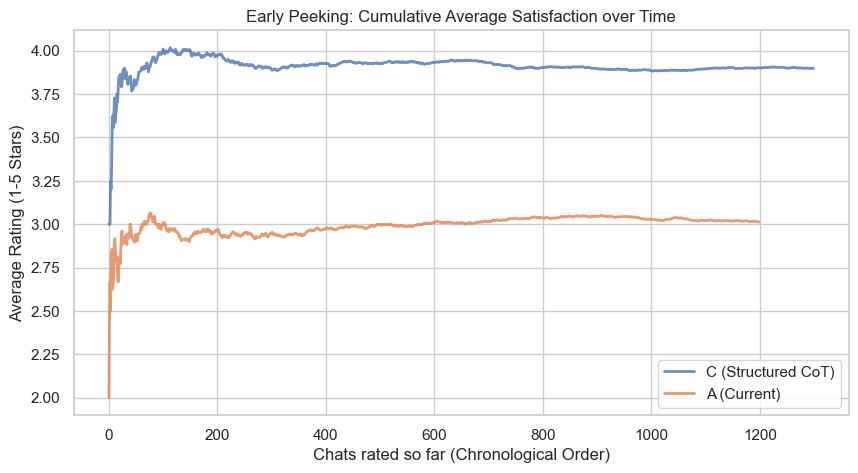

In [4]:
plt.figure(figsize=(10, 5))

for variant in df['variant'].unique():
    var_data = df[df['variant'] == variant].copy()
    # Calculate rolling average score as new chats come in
    var_data['cum_mean'] = var_data['score'].expanding().mean()
    plt.plot(var_data['cum_mean'].values, label=variant, alpha=0.8, linewidth=2)

plt.title('Early Peeking: Cumulative Average Satisfaction over Time')
plt.xlabel('Chats rated so far (Chronological Order)')
plt.ylabel('Average Rating (1-5 Stars)')
plt.legend()
plt.show()

## Cell 4: Final Visualization & Statistical Analysis (T-Test)

This cell generates your final presentation chart and calculates the p-value. Because you are testing averages (1-5) rather than binary clicks (0/1), we use a T-Test instead of a Z-Test.

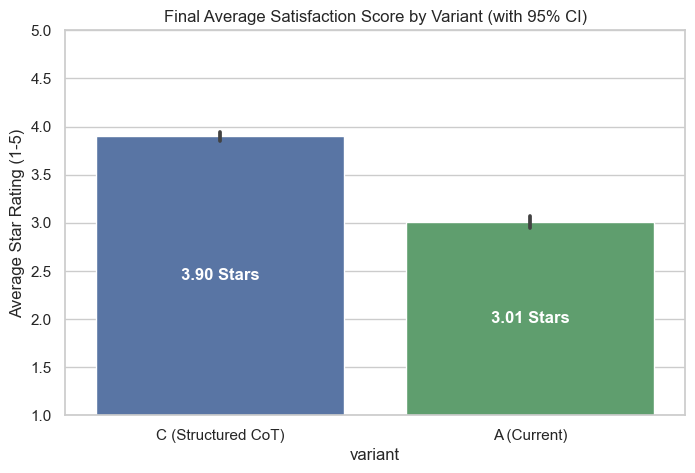

--- Final Statistical Results ---
Control (A) Mean: 3.01
Test (C) Mean:    3.90
Relative Uplift:  +29.4%
P-Value:          0.000000
Significant?      YES


In [5]:
# 1. Visualization
summary = df.groupby('variant')['score'].agg(['count', 'mean', 'std']).reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='variant', y='score', errorbar=('ci', 95), palette=['#4C72B0', '#55A868'])
plt.title('Final Average Satisfaction Score by Variant (with 95% CI)')
plt.ylabel('Average Star Rating (1-5)')
plt.ylim(1, 5) # Lock y-axis to possible scores

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f Stars', label_type='center', color='white', fontweight='bold')
plt.show()

# 2. Statistical Testing (Independent T-Test)
scores_A = df[df['variant'] == 'A (Current)']['score']
scores_C = df[df['variant'] == 'C (Structured CoT)']['score']

stat, pval = stats.ttest_ind(scores_C, scores_A, equal_var=False)
uplift = ((scores_C.mean() - scores_A.mean()) / scores_A.mean()) * 100
is_sig = "YES" if pval < 0.05 else "NO"

print("--- Final Statistical Results ---")
print(f"Control (A) Mean: {scores_A.mean():.2f}")
print(f"Test (C) Mean:    {scores_C.mean():.2f}")
print(f"Relative Uplift:  +{uplift:.1f}%")
print(f"P-Value:          {pval:.6f}")
print(f"Significant?      {is_sig}")